In [1]:
import pickle
import numpy as np
import mne
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kstest, levene, ttest_ind, mannwhitneyu

In [2]:
def load_pickle_data(file_path):
    with open(file_path, 'rb') as f:
        return pickle.load(f)


coh_base_dir = '../data/COH/'  
pli_base_dir = '../data/PLI/' 
ste_base_dir = '../data/STE/'


BD_coh = load_pickle_data(coh_base_dir + 'BD_coh_data.pkl')
MDD_coh = load_pickle_data(coh_base_dir + 'MDD_coh_data.pkl')
BD_pli = load_pickle_data(pli_base_dir + 'BD_pli_data.pkl')
MDD_pli = load_pickle_data(pli_base_dir + 'MDD_pli_data.pkl')
BD_ste = load_pickle_data(ste_base_dir + 'BD_ste_data.pkl')
MDD_ste = load_pickle_data(ste_base_dir + 'MDD_ste_data.pkl')


eloc29_path = "../電極通道/BD_MDD_HC_29_test.loc"
eloc29 = mne.channels.read_custom_montage(eloc29_path)
ch_names = eloc29.ch_names

frequency_bands = ['delta', 'theta', 'alpha', 'betalow', 'betahigh', 'gamma']
alpha = 0.05  


n_chan_pairs = len(np.triu_indices(len(ch_names), k=1)[0])                  # COH、PLI same pairs
n_ste_pairs = len(ch_names) * (len(ch_names) - 1)                           # STE 
total_tests = 6 * n_chan_pairs * 2 + 6 * n_ste_pairs
bonf_alpha = alpha / total_tests
print(f"Bonferroni-corrected alpha = {bonf_alpha:.2e} (alpha={alpha}/tests={total_tests})")


Bonferroni-corrected alpha = 5.13e-06 (alpha=0.05/tests=9744)


In [3]:
def test_feature(dist1, dist2, alpha_normal=0.05, alpha_levene=0.05):

    # 1. 正態性檢定
    _, p1 = kstest(dist1, 'norm', args=(np.mean(dist1), np.std(dist1, ddof=1)))
    _, p2 = kstest(dist2, 'norm', args=(np.mean(dist2), np.std(dist2, ddof=1)))

    if p1 > alpha_normal and p2 > alpha_normal:
        # 2. 同方差性檢定
        stat_levene, p_levene = levene(dist1, dist2)
        
        if p_levene > alpha_levene:
            # 等變異：Student’s t-test
            stat, pval = ttest_ind(dist1, dist2, equal_var=True)
            test_name = "Student’s t-test"
        else:
            # 不等變異：Welch’s t-test
            stat, pval = ttest_ind(dist1, dist2, equal_var=False)
            test_name = "Welch’s t-test"
    else:

        stat, pval = mannwhitneyu(dist1, dist2, alternative='two-sided')
        test_name = "Mann–Whitney U test"

    return test_name, pval

In [ ]:
def test_feature(dist1, dist2):
    #  K–S normality test
    _, p1 = kstest(dist1, 'norm', args=(np.mean(dist1), np.std(dist1, ddof=1)))
    _, p2 = kstest(dist2, 'norm', args=(np.mean(dist2), np.std(dist2, ddof=1)))

    if p1 > alpha and p2 > alpha:
        stat, pval = ttest_ind(dist1, dist2, equal_var=False)
        test_name = "t-test"
    else:
        stat, pval = mannwhitneyu(dist1, dist2, alternative='two-sided')
        test_name = "Mann-Whitney U"
    return test_name, pval


In [4]:
def decode_coh_feature(band_idx, pair_idx):
    band = frequency_bands[band_idx]
    r, c = np.triu_indices(len(ch_names), k=1)
    return f"COH | {band} | {ch_names[r[pair_idx]]}-{ch_names[c[pair_idx]]}"

def decode_pli_feature(band_idx, pair_idx):
    band = frequency_bands[band_idx]
    r, c = np.triu_indices(len(ch_names), k=1)
    return f"PLI | {band} | {ch_names[r[pair_idx]]}-{ch_names[c[pair_idx]]}"

def decode_ste_feature(band_idx, pair_idx):
    band = frequency_bands[band_idx]
    # 所有有向對 (i != j)
    ste_pairs = [(i, j) for i in range(len(ch_names)) for j in range(len(ch_names)) if i != j]
    i, j = ste_pairs[pair_idx]
    return f"STE | {band} | {ch_names[i]}→{ch_names[j]}"

In [5]:
BD_subjects = sorted(BD_coh.keys())
MDD_subjects = sorted(MDD_coh.keys())


results = {'COH': [], 'PLI': [], 'STE': []}

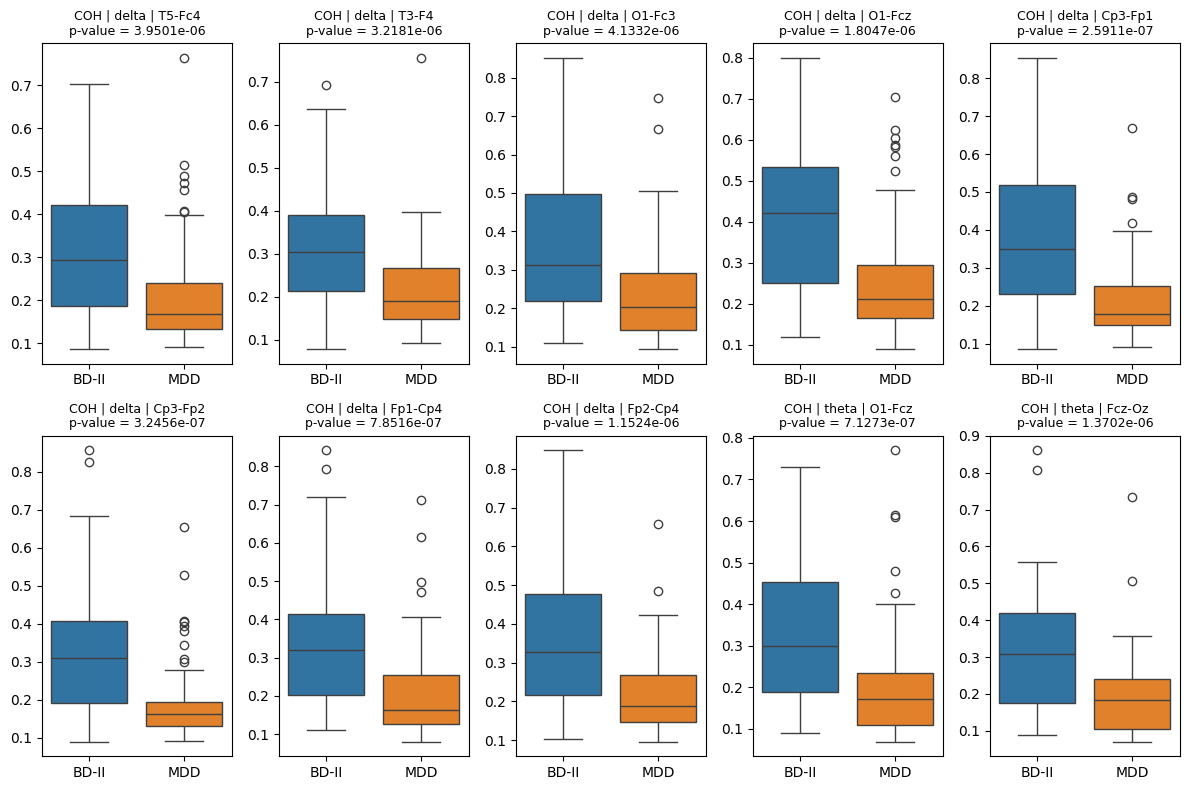

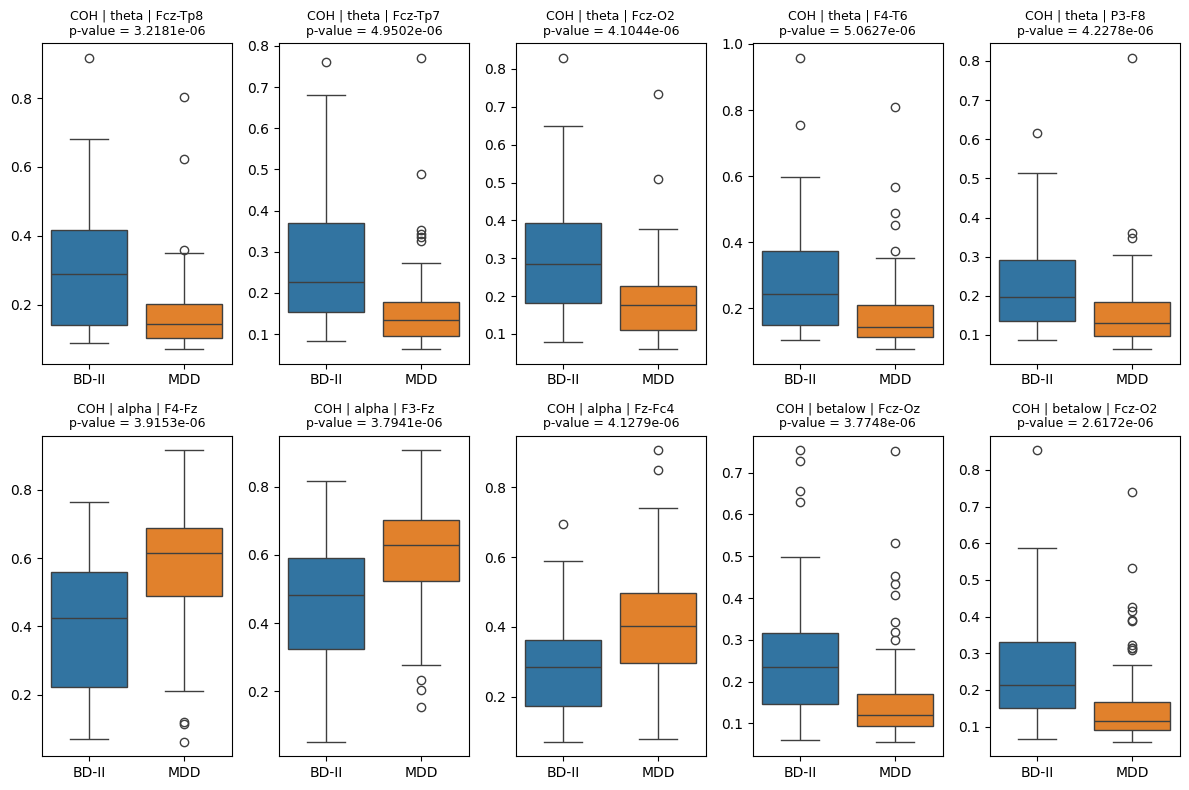

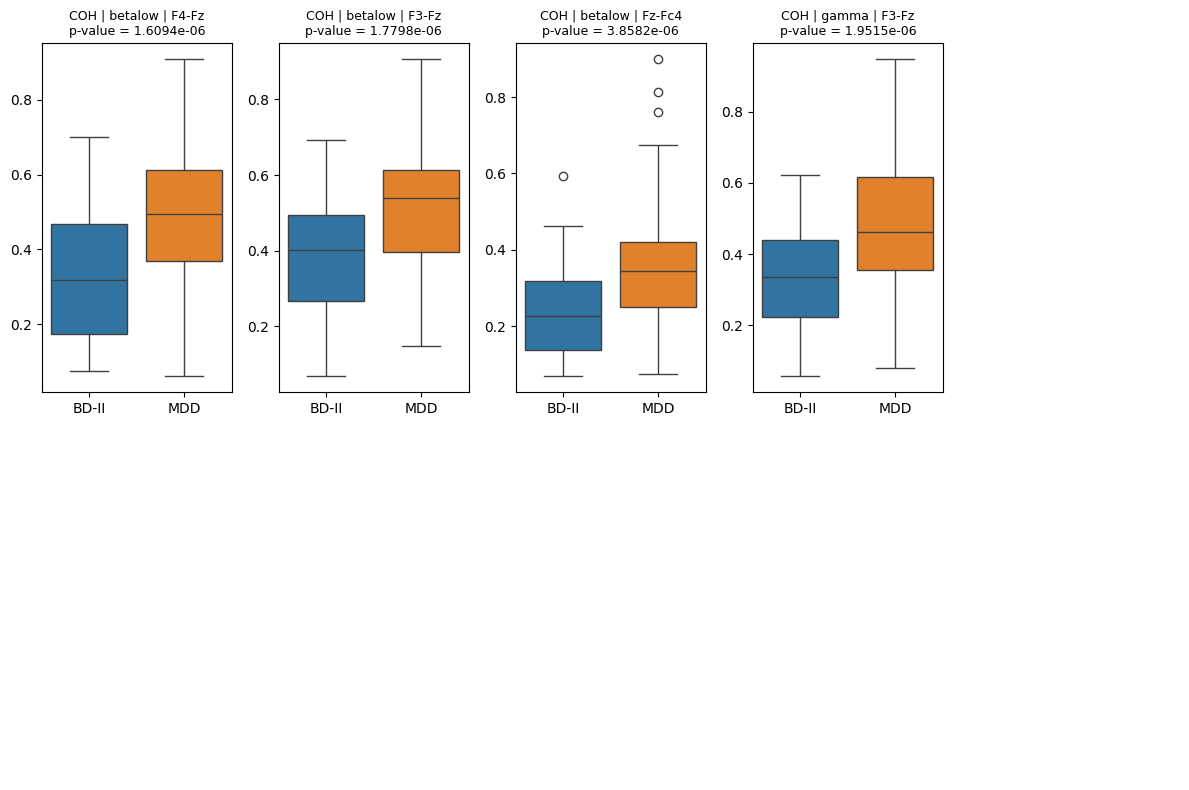

In [6]:
# ---------------------- COH ----------------------
results['COH'] = []

for b_idx, band in enumerate(frequency_bands):
    BD_mat = np.array([BD_coh[s][band] for s in BD_subjects])
    MDD_mat = np.array([MDD_coh[s][band] for s in MDD_subjects])
    for pair_idx in range(n_chan_pairs):
        bd_vals = BD_mat[:, pair_idx]
        mdd_vals = MDD_mat[:, pair_idx]
        _, pval = test_feature(bd_vals, mdd_vals)
        if pval < bonf_alpha:
            desc = decode_coh_feature(b_idx, pair_idx)
            results['COH'].append((desc, pval, bd_vals, mdd_vals))


batch_size = 10
for start in range(0, len(results['COH']), batch_size):
    batch = results['COH'][start:start + batch_size]
    fig, axes = plt.subplots(2, 5, figsize=(12, 8), dpi=100) 
    for idx, (desc, pval, bd_vals, mdd_vals) in enumerate(batch):
        ax = axes.flat[idx]
        sns.boxplot(data=[bd_vals, mdd_vals], ax=ax)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['BD-II', 'MDD'])
        ax.set_title(f"{desc}\np-value = {pval:.4e}", fontsize=9)

    for idx in range(len(batch), 2*5):
        axes.flat[idx].axis('off')
    plt.tight_layout()
    plt.show()

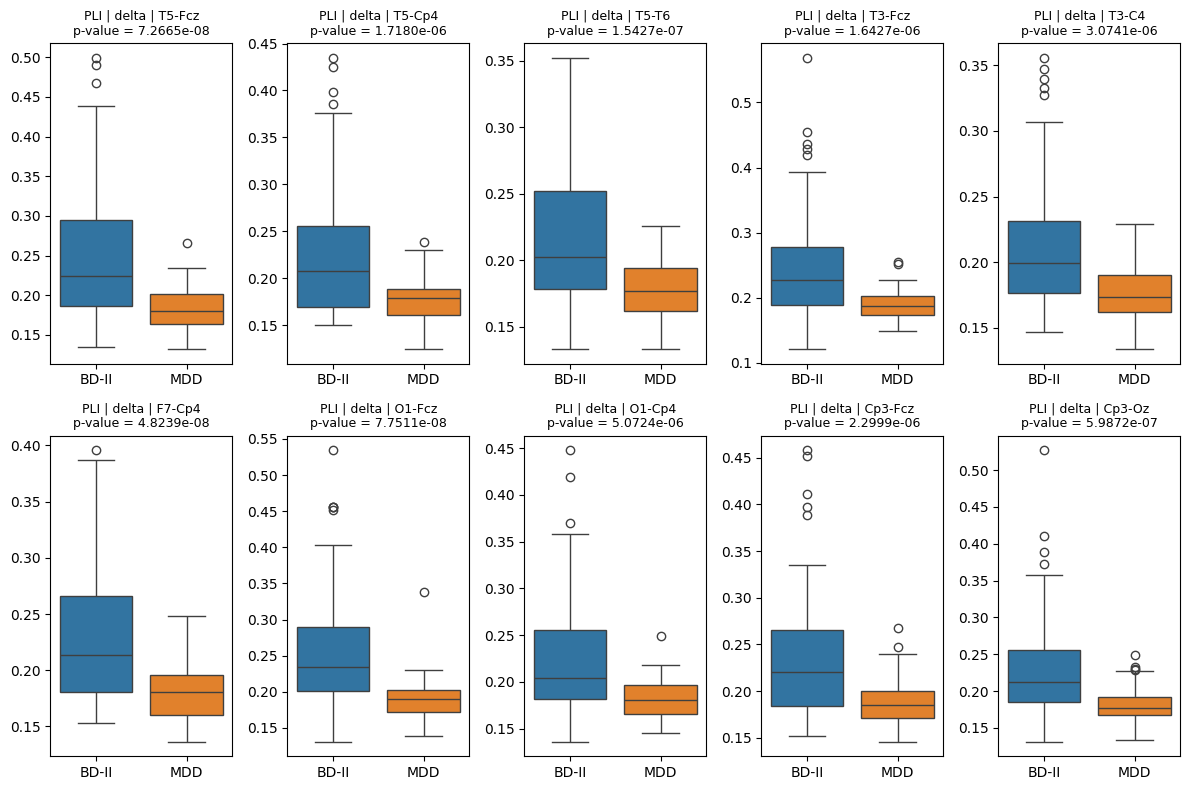

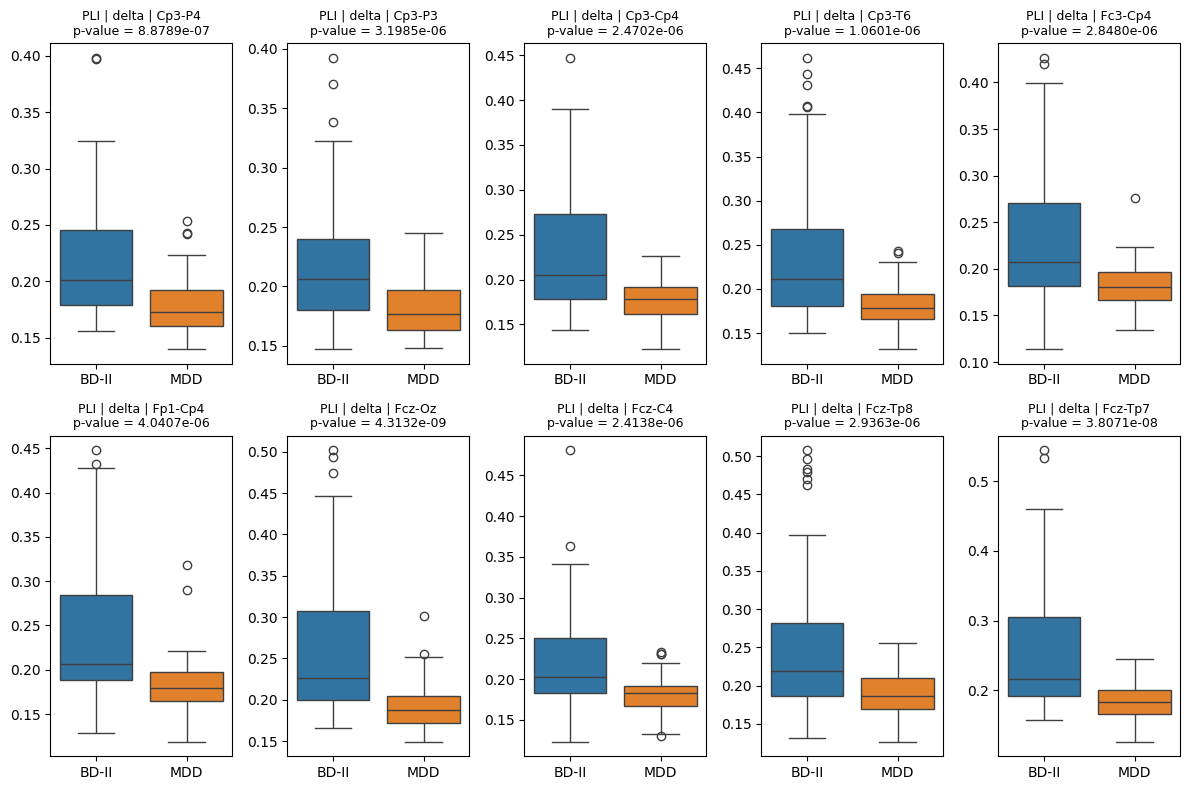

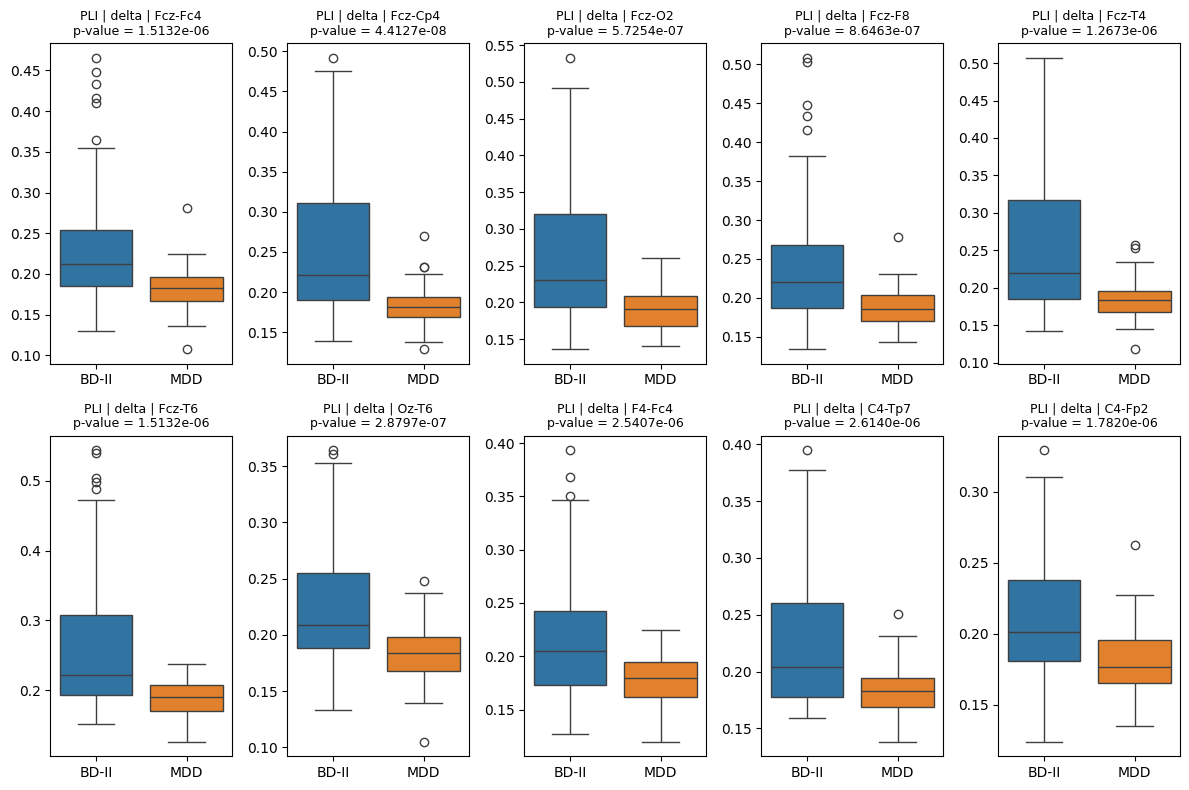

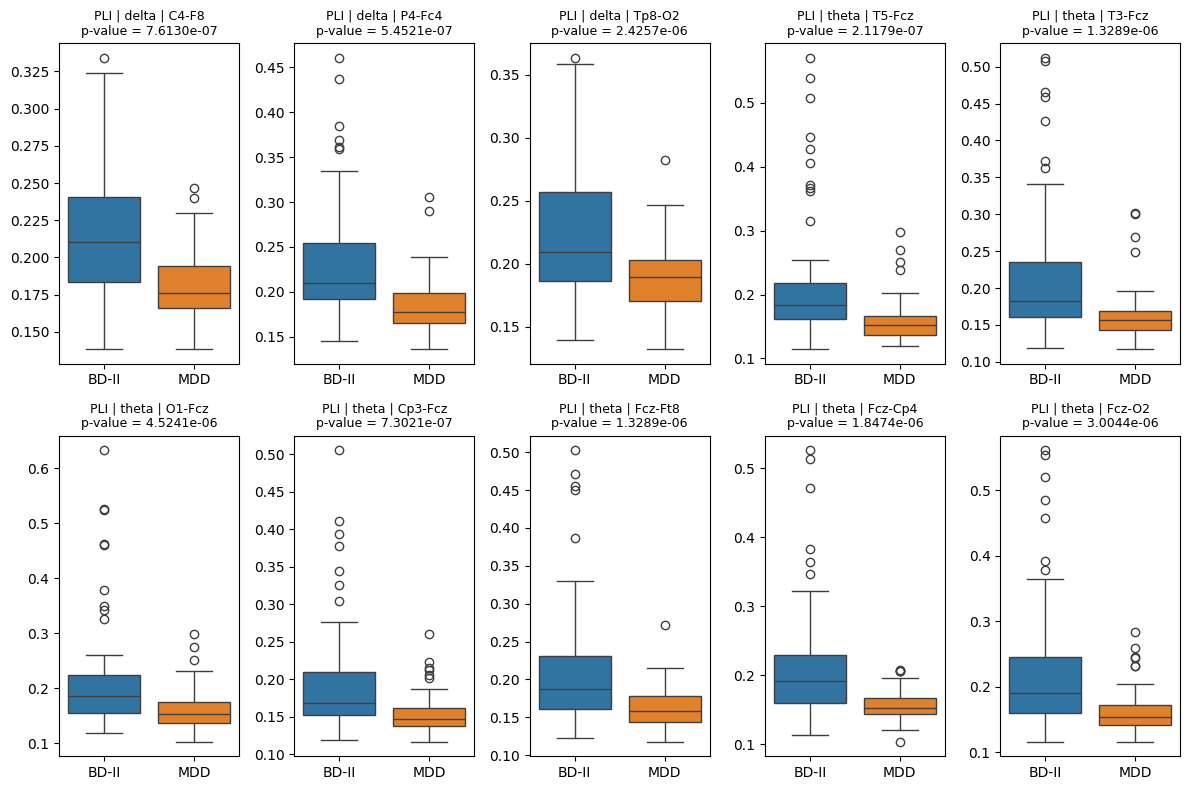

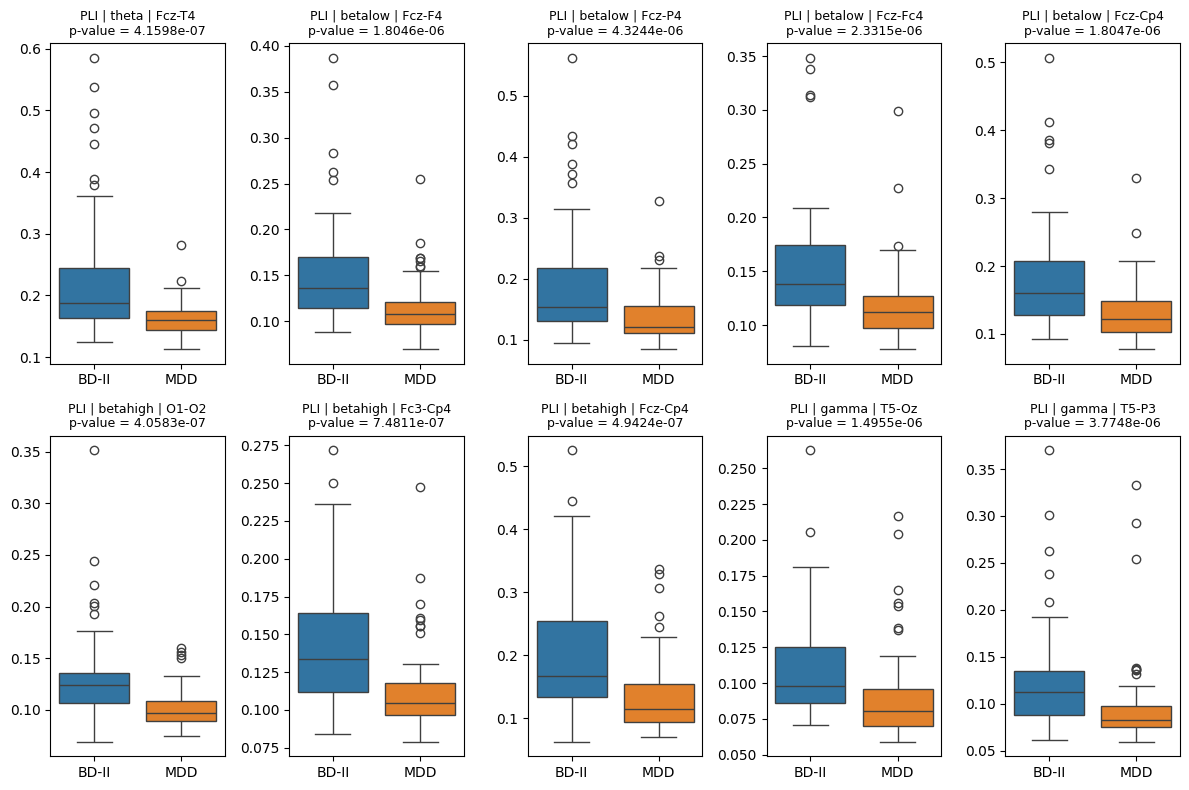

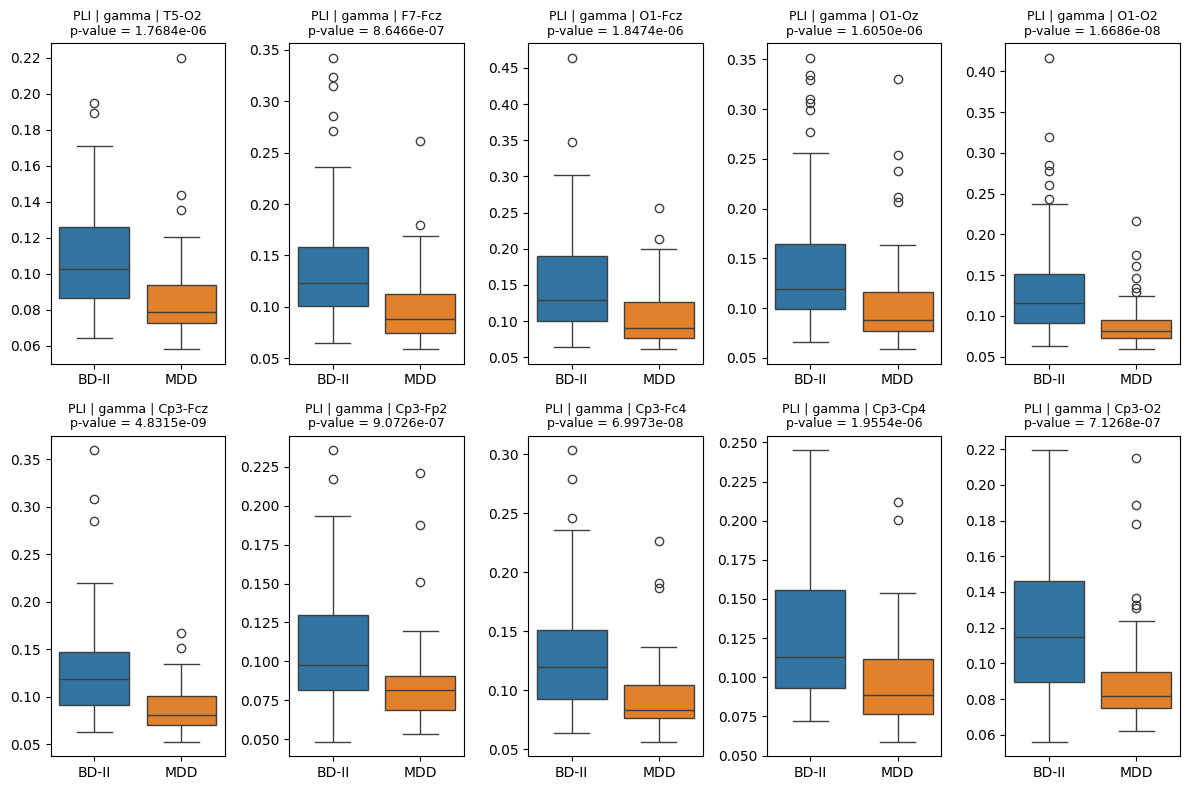

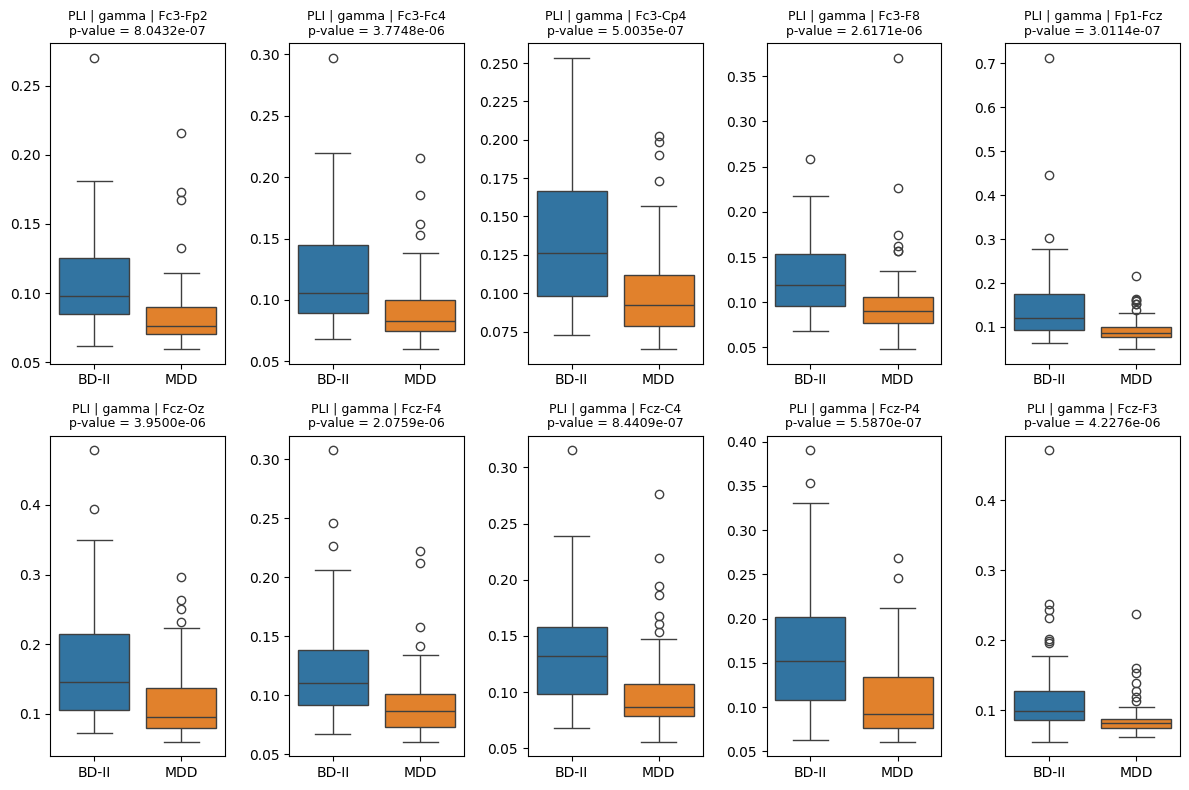

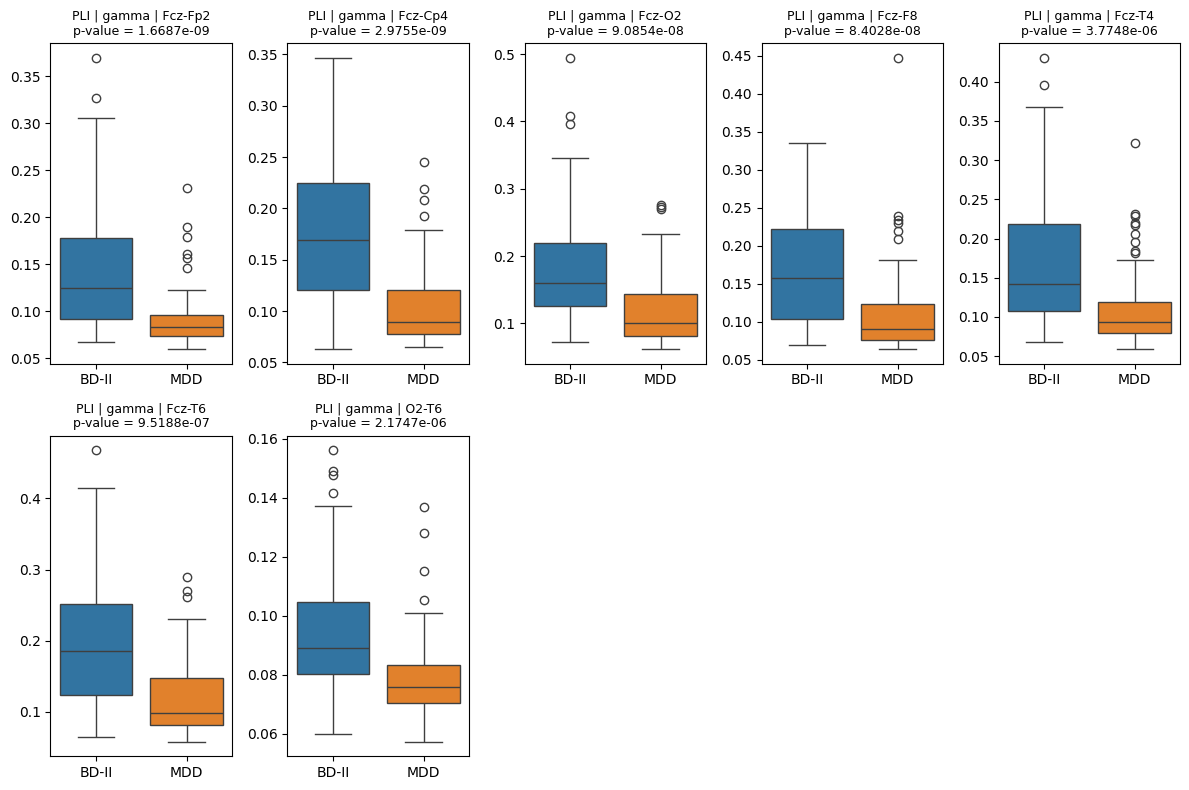

In [7]:
# ---------------------- PLI ----------------------
results['PLI'] = []

for b_idx, band in enumerate(frequency_bands):
    BD_mat = np.array([BD_pli[s][band] for s in BD_subjects])
    MDD_mat = np.array([MDD_pli[s][band] for s in MDD_subjects])
    for pair_idx in range(n_chan_pairs):
        bd_vals = BD_mat[:, pair_idx]
        mdd_vals = MDD_mat[:, pair_idx]
        _, pval = test_feature(bd_vals, mdd_vals)
        if pval < bonf_alpha:
            desc = decode_pli_feature(b_idx, pair_idx)
            results['PLI'].append((desc, pval, bd_vals, mdd_vals))



for start in range(0, len(results['PLI']), batch_size):
    batch = results['PLI'][start:start + batch_size]
    fig, axes = plt.subplots(2, 5, figsize=(12, 8), dpi=100)
    for idx, (desc, pval, bd_vals, mdd_vals) in enumerate(batch):
        ax = axes.flat[idx]
        sns.boxplot(data=[bd_vals, mdd_vals], ax=ax)
        ax.set_xticks([0, 1]); ax.set_xticklabels(['BD-II', 'MDD'])
        ax.set_title(f"{desc}\np-value = {pval:.4e}", fontsize=9)

    for idx in range(len(batch), 10):
        axes.flat[idx].axis('off')
    plt.tight_layout()
    plt.show()

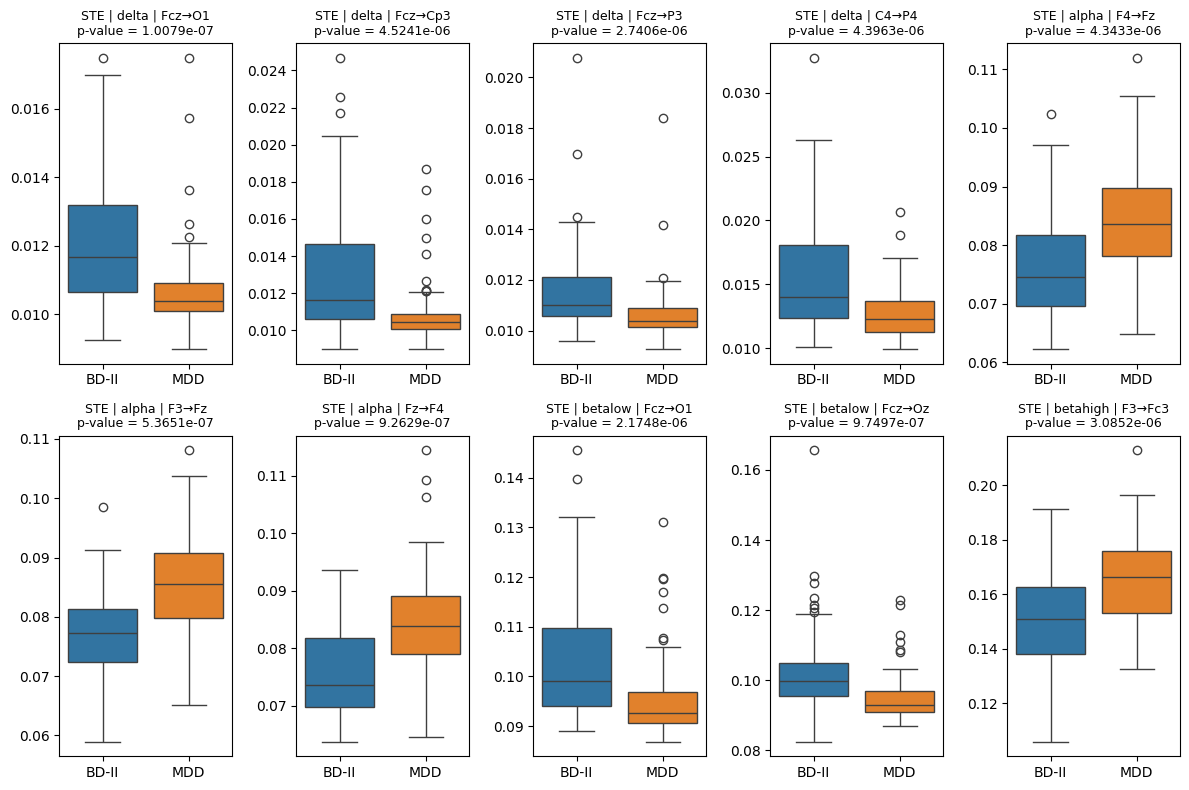

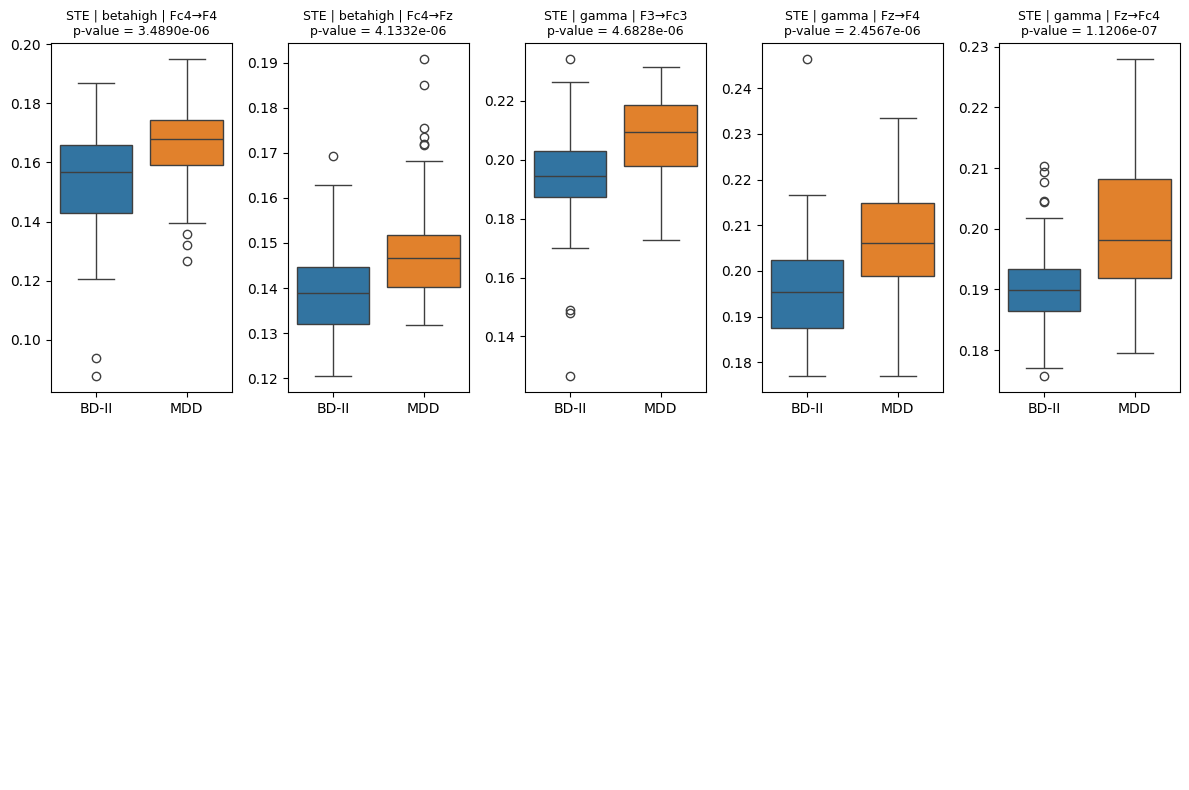

In [8]:
# ---------------------- STE ----------------------
results['STE'] = []

ste_mask = ~np.eye(len(ch_names), dtype=bool)
for b_idx, band in enumerate(frequency_bands):
    BD_mat = np.array([BD_ste[s][band][ste_mask] for s in BD_subjects])
    MDD_mat = np.array([MDD_ste[s][band][ste_mask] for s in MDD_subjects])
    for pair_idx in range(n_ste_pairs):
        bd_vals = BD_mat[:, pair_idx]
        mdd_vals = MDD_mat[:, pair_idx]
        _, pval = test_feature(bd_vals, mdd_vals)
        if pval < bonf_alpha:
            desc = decode_ste_feature(b_idx, pair_idx)
            results['STE'].append((desc, pval, bd_vals, mdd_vals))


for start in range(0, len(results['STE']), batch_size):
    batch = results['STE'][start:start + batch_size]
    fig, axes = plt.subplots(2, 5, figsize=(12, 8), dpi=100)
    for idx, (desc, pval, bd_vals, mdd_vals) in enumerate(batch):
        ax = axes.flat[idx]
        sns.boxplot(data=[bd_vals, mdd_vals], ax=ax)
        ax.set_xticks([0, 1]); ax.set_xticklabels(['BD-II', 'MDD'])
        ax.set_title(f"{desc}\np-value = {pval:.4e}", fontsize=9)

    for idx in range(len(batch), 10):
        axes.flat[idx].axis('off')
    plt.tight_layout()
    plt.show()

PLI | gamma | Fcz-Fp2, p = 1.6687e-09
PLI | gamma | Fcz-Cp4, p = 2.9755e-09
PLI | delta | Fcz-Oz, p = 4.3132e-09
PLI | gamma | Cp3-Fcz, p = 4.8315e-09
PLI | gamma | O1-O2, p = 1.6686e-08
PLI | delta | Fcz-Tp7, p = 3.8071e-08
PLI | delta | Fcz-Cp4, p = 4.4127e-08
PLI | delta | F7-Cp4, p = 4.8239e-08
PLI | gamma | Cp3-Fc4, p = 6.9973e-08
PLI | delta | T5-Fcz, p = 7.2665e-08


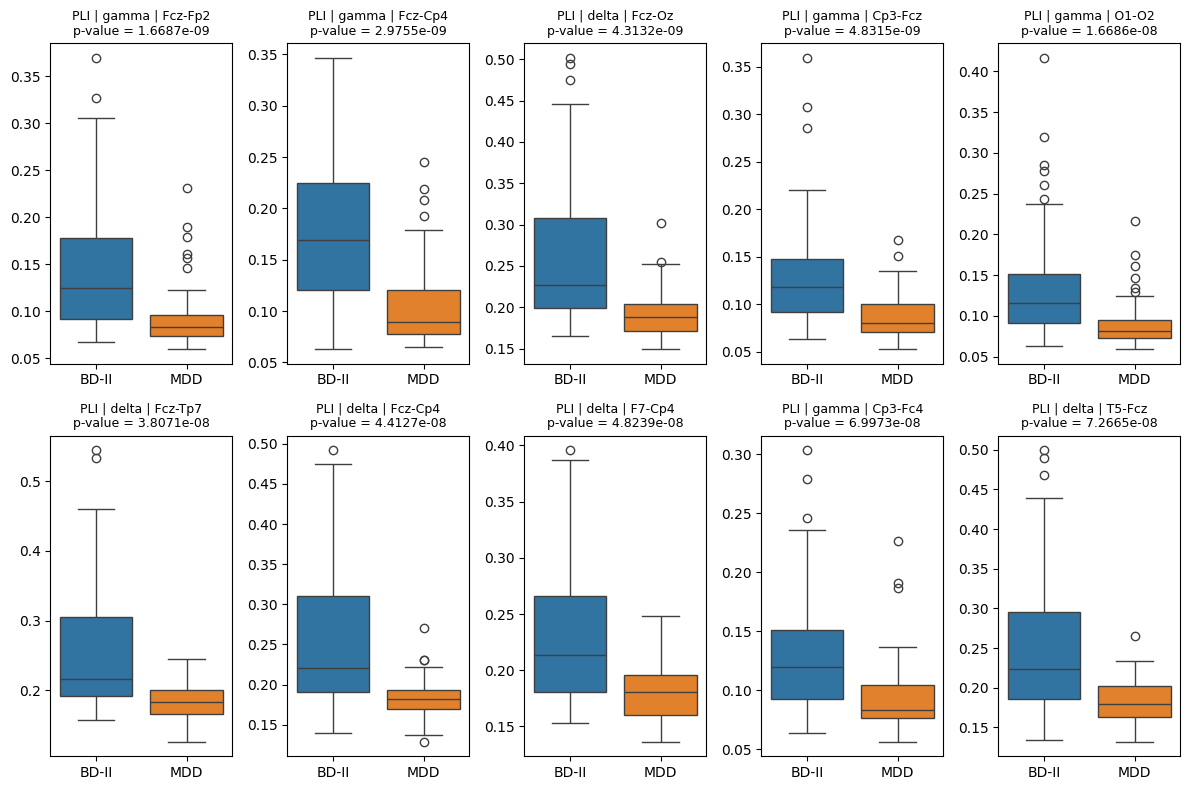

In [9]:
all_results = results['COH'] + results['PLI'] + results['STE']

all_results_sorted = sorted(all_results, key=lambda x: x[1])
top10 = all_results_sorted[:10]



for desc, pval, _, _ in top10:
    print(f"{desc}, p = {pval:.4e}")


fig, axes = plt.subplots(2, 5, figsize=(12, 8), dpi=100)
for idx, (desc, pval, bd_vals, mdd_vals) in enumerate(top10):
    ax = axes.flat[idx]
    sns.boxplot(data=[bd_vals, mdd_vals], ax=ax)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['BD-II', 'MDD'])
    ax.set_title(f"{desc}\np-value = {pval:.4e}", fontsize=9)


for idx in range(len(top10), 10):
    axes.flat[idx].axis('off')

plt.tight_layout()
plt.show()


In [11]:
from collections import Counter


def get_electrode_counts(result_list):
    cnt = Counter()
    for desc, pval, bd_vals, mdd_vals in result_list:
        # 解析出 "ch1-ch2" 或 "ch1→ch2"
        pair = desc.split('|')[-1].strip()
        if '→' in pair:
            ch1, ch2 = pair.split('→')
        else:
            ch1, ch2 = pair.split('-')
        cnt[ch1] += 1
        cnt[ch2] += 1
    return cnt


counts_coh = get_electrode_counts(results['COH'])
counts_pli = get_electrode_counts(results['PLI'])
counts_ste = get_electrode_counts(results['STE'])


top5_coh = counts_coh.most_common(5)
top5_pli = counts_pli.most_common(5)
top5_ste = counts_ste.most_common(5)

print("=== COH most used 5 electrodes ===")
for ch, cnt in top5_coh:
    print(f"{ch}: {cnt}")

print("\n=== PLI most used 5 electrodes ===")
for ch, cnt in top5_pli:
    print(f"{ch}: {cnt}")

print("\n=== STE most used 5 electrodes ===")
for ch, cnt in top5_ste:
    print(f"{ch}: {cnt}")






counts_all = counts_coh + counts_pli + counts_ste
top10_all = counts_all.most_common(10)

print("\n==Overall most used 10 electrodes ===")
for ch, cnt in top10_all:
    print(f"{ch}: {cnt}")


=== COH most used 5 electrodes ===
Fcz: 8
Fz: 7
F4: 4
Fc4: 3
O1: 3

=== PLI most used 5 electrodes ===
Fcz: 42
Cp4: 14
Cp3: 12
O2: 9
T5: 7

=== STE most used 5 electrodes ===
Fz: 6
Fcz: 5
F4: 4
F3: 3
Fc4: 3

==Overall most used 10 electrodes ===
Fcz: 55
Cp4: 16
Cp3: 15
Fz: 13
Fc4: 12
O1: 12
F4: 11
O2: 11
Fc3: 9
Oz: 9
